In [2]:
# Step 0(Imports)

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense, Flatten, Conv1D, MaxPooling1D,
    LSTM, GRU, Input, Attention
)
from tensorflow.keras.optimizers import Adam


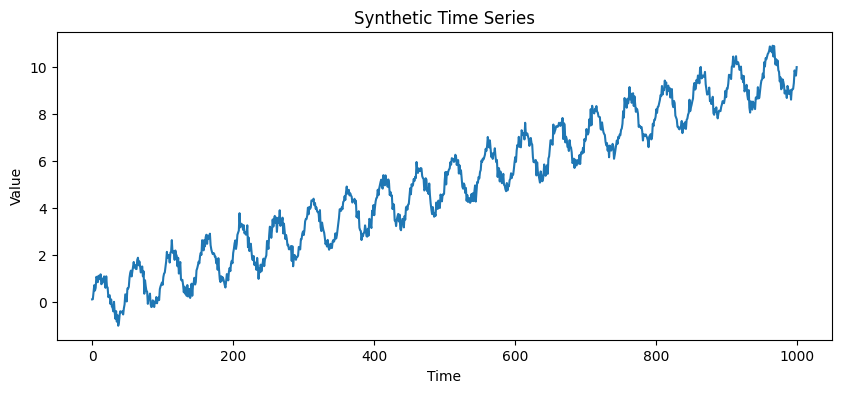

In [3]:
# Step 1(Generate Synthetic Time-Series Data)

np.random.seed(42)

t = np.arange(0, 1000)
trend = 0.01 * t
seasonal = np.sin(2 * np.pi * t / 50)
noise = np.random.normal(0, 0.2, len(t))

series = trend + seasonal + noise

plt.figure(figsize=(10, 4))
plt.plot(series)
plt.title("Synthetic Time Series")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()


In [4]:
# Step 2(Convert to Supervised Learning)

def create_sequences(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i + window])
        y.append(data[i + window])
    return np.array(X), np.array(y)

WINDOW_SIZE = 20

X, y = create_sequences(series, WINDOW_SIZE)
X = X.reshape((X.shape[0], X.shape[1], 1))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


In [5]:
# Step 3(Baseline MLP Model)

mlp = Sequential([
    Flatten(input_shape=(WINDOW_SIZE, 1)),
    Dense(64, activation='relu'),
    Dense(1)
])

mlp.compile(optimizer=Adam(0.001), loss='mse')
mlp.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

y_pred_mlp = mlp.predict(X_test)
rmse_mlp = np.sqrt(mean_squared_error(y_test, y_pred_mlp))

print("MLP RMSE:", rmse_mlp)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
MLP RMSE: 0.35483174590473754


In [6]:
# Step 4(1D CNN Model)

cnn = Sequential([
    Conv1D(32, 3, activation='relu', input_shape=(WINDOW_SIZE, 1)),
    MaxPooling1D(2),
    Flatten(),
    Dense(1)
])

cnn.compile(optimizer=Adam(0.001), loss='mse')
cnn.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

y_pred_cnn = cnn.predict(X_test)
rmse_cnn = np.sqrt(mean_squared_error(y_test, y_pred_cnn))

print("CNN RMSE:", rmse_cnn)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
CNN RMSE: 0.50659359227032


In [7]:
# Step 5(LSTM Model)

lstm = Sequential([
    LSTM(50, input_shape=(WINDOW_SIZE, 1)),
    Dense(1)
])

lstm.compile(optimizer=Adam(0.001), loss='mse')
lstm.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

y_pred_lstm = lstm.predict(X_test)
rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred_lstm))

print("LSTM RMSE:", rmse_lstm)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step
LSTM RMSE: 1.1240201661170774


In [8]:
# Step 6(GRU Model)

gru = Sequential([
    GRU(50, input_shape=(WINDOW_SIZE, 1)),
    Dense(1)
])

gru.compile(optimizer=Adam(0.001), loss='mse')
gru.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

y_pred_gru = gru.predict(X_test)
rmse_gru = np.sqrt(mean_squared_error(y_test, y_pred_gru))

print("GRU RMSE:", rmse_gru)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
GRU RMSE: 1.1821689851490853


In [9]:
# Step 7&8(CNN-LSTM + Attention Models)

# CNN-LSTM
cnn_lstm = Sequential([
    Conv1D(32, 3, activation='relu', input_shape=(WINDOW_SIZE, 1)),
    MaxPooling1D(2),
    LSTM(50),
    Dense(1)
])

cnn_lstm.compile(optimizer=Adam(0.001), loss='mse')
cnn_lstm.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

y_pred_cnn_lstm = cnn_lstm.predict(X_test)
rmse_cnn_lstm = np.sqrt(mean_squared_error(y_test, y_pred_cnn_lstm))

print("CNN-LSTM RMSE:", rmse_cnn_lstm)


# Attention Model
inputs = Input(shape=(WINDOW_SIZE, 1))
lstm_out = LSTM(50, return_sequences=True)(inputs)
attn_out = Attention()([lstm_out, lstm_out])
flat = Flatten()(attn_out)
output = Dense(1)(flat)

attn_model = Model(inputs, output)
attn_model.compile(optimizer=Adam(0.001), loss='mse')
attn_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

y_pred_attn = attn_model.predict(X_test)
rmse_attn = np.sqrt(mean_squared_error(y_test, y_pred_attn))

print("Attention RMSE:", rmse_attn)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
CNN-LSTM RMSE: 0.8126758165988384
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Attention RMSE: 1.058702249281745


In [10]:
# Step 9(Final Comparison)

print("\nMODEL COMPARISON (RMSE)")
print("----------------------")
print("MLP       :", rmse_mlp)
print("CNN       :", rmse_cnn)
print("LSTM      :", rmse_lstm)
print("GRU       :", rmse_gru)
print("CNN-LSTM  :", rmse_cnn_lstm)
print("Attention :", rmse_attn)



MODEL COMPARISON (RMSE)
----------------------
MLP       : 0.35483174590473754
CNN       : 0.50659359227032
LSTM      : 1.1240201661170774
GRU       : 1.1821689851490853
CNN-LSTM  : 0.8126758165988384
Attention : 1.058702249281745
